### Visión por Computadora — TP3

Autor: Nicolás Rodrigues da Cruz (a2123)

Encontrar el logotipo de la gaseosa dentro de las imagenes que se encuentran en la carpeta de Material TPs a partir del template provisto.

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

IMG_DIR = Path('../Material_TPs/TP3/images')
TEMPLATE_PATH = Path('../Material_TPs/TP3/template/pattern.png')

#### Punto 1: Obtener una detección de logo en cada imagen sin falsos positivos

Para resolver este punto implemento un pipeline de detección por template matching reforzado con bordes, multiescala y pequeñas rotaciones. Para reducir falsos positivos, acoto la búsqueda a regiones de interés detectadas por color (rojo) y/o blanco (en algunos casos) en la ventana candidata. En casos difíciles incorporo dos estrategias de respaldo: un barrido global multiescala sobre bordes y un detector basado en características (AKAZE + homografía) para cubrir deformaciones de perspectiva. En ultima instancia se hace la selección de la mejor caja por score y su visualización.

Defino funciones básicas de conversión y dibujo. Se utiliza BGR porque es el espacio por defecto en OpenCV y convierto a RGB sólo para visualizar con Matplotlib. La función de dibujo incluye el score de la detección con dos decimales para poder comparar resultados.

In [2]:
def to_gray(bgr):
    return cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)

def to_rgb(bgr):
    return cv.cvtColor(bgr, cv.COLOR_BGR2RGB)

def draw_box(rgb, tl, w, h, score=None, color=(0, 255, 0), thick=2):
    """Dibuja un rectángulo con el score en pantalla."""
    x, y = map(int, tl)
    cv.rectangle(rgb, (x, y), (x + w, y + h), color, thick)
    if score is not None:
        cv.putText(rgb, f"{score:.2f}", (x, max(0, y - 8)),
                   cv.FONT_HERSHEY_SIMPLEX, 0.6, color, 2, cv.LINE_AA)

Roto la imagen alrededor del centro sin recortar para probar ángulos pequeños. El filtro unsharp realza bordes suaves para que Canny responda mejor.

In [3]:
def unsharp(g, sigma=1.8, amount=1.3):
    blur = cv.GaussianBlur(g, (0, 0), sigmaX=sigma)
    return cv.addWeighted(g, 1 + amount, blur, -amount, 0)

def rotate_image(g, angle_deg):
    """Rota una imagen en su centro sin recorte."""
    h, w = g.shape[:2]
    M = cv.getRotationMatrix2D((w / 2, h / 2), angle_deg, 1.0)
    cos, sin = abs(M[0, 0]), abs(M[0, 1])
    nW = int((h * sin) + (w * cos))
    nH = int((h * cos) + (w * sin))
    M[0, 2] += (nW / 2) - w / 2
    M[1, 2] += (nH / 2) - h / 2
    return cv.warpAffine(g, M, (nW, nH), flags=cv.INTER_LINEAR, borderMode=cv.BORDER_REPLICATE)

Calculo bordes con Canny ajustando umbrales según la mediana de la imagen. Mantengo una versión normal y otra más permisiva para escenas de bajo contraste, y cierro pequeñas brechas con morfología.

In [4]:
_K3 = np.ones((3, 3), np.uint8)

def edges(g):
    g2 = unsharp(g)
    v = np.median(g2)
    lo = int(max(0, 0.66 * v))
    hi = int(min(255, 1.33 * v))
    e = cv.Canny(g2, lo, hi)
    return cv.morphologyEx(e, cv.MORPH_CLOSE, _K3, 1)

def edges_loose(g):
    g2 = unsharp(g, sigma=1.6, amount=1.1)
    v = np.median(g2)
    lo = int(max(0, 0.45 * v))
    hi = int(min(255, 1.10 * v))
    e = cv.Canny(g2, lo, hi)
    return cv.morphologyEx(e, cv.MORPH_CLOSE, _K3, 1)

Creo máscaras en HSV para encontrar zonas rojas y blancas y las limpio con operaciones morfológicas. La de blanco queda en formato 0/1 para promediar dentro de ventanas.

In [5]:
def red_mask(bgr):
    hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
    m1 = cv.inRange(hsv, (0, 80, 60),  (12, 255, 255))
    m2 = cv.inRange(hsv, (170, 80, 60), (180, 255, 255))
    m  = cv.bitwise_or(m1, m2)
    k  = np.ones((5, 5), np.uint8)
    m  = cv.morphologyEx(m, cv.MORPH_CLOSE, k, 1)
    m  = cv.morphologyEx(m, cv.MORPH_OPEN,  k, 1)
    return m

def white_mask(bgr):
    hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
    m = cv.inRange(hsv, (0, 0, 200), (180, 60, 255))
    k = np.ones((3, 3), np.uint8)
    m = cv.morphologyEx(m, cv.MORPH_OPEN,  k, 1)
    m = cv.morphologyEx(m, cv.MORPH_CLOSE, k, 1)
    return (m > 0).astype(np.float32)


A partir del rojo saco rectángulos de búsqueda con un pequeño padding para acelerar el matching. Luego aplico supresión no máxima para quedarme con las cajas más fuertes sin duplicados.

In [6]:

def rois_from_red(mask, min_area=800):
    cnts, _ = cv.findContours(mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    rois = []
    H, W = mask.shape[:2]

    for c in cnts:
        x, y, w, h = cv.boundingRect(c)
        if w * h < min_area:
            continue
        pad = int(0.06 * max(w, h))
        x0 = max(0, x - pad)
        y0 = max(0, y - pad)
        x1 = min(W, x + w + pad)
        y1 = min(H, y + h + pad)
        rois.append((x0, y0, x1 - x0, y1 - y0))

    return rois or [(0, 0, W, H)]

def nms(boxes, iou_thresh=0.3):
    if not boxes:
        return []
    b = np.array(boxes, dtype=np.float32)
    x, y, w, h, s = b[:, 0], b[:, 1], b[:, 2], b[:, 3], b[:, 4]
    x2, y2 = x + w, y + h
    idxs = np.argsort(s)
    pick = []

    while len(idxs) > 0:
        last = idxs[-1]
        pick.append(last)
        xx1 = np.maximum(x[last],  x[idxs[:-1]])
        yy1 = np.maximum(y[last],  y[idxs[:-1]])
        xx2 = np.minimum(x2[last], x2[idxs[:-1]])
        yy2 = np.minimum(y2[last], y2[idxs[:-1]])
        wI  = np.maximum(0, xx2 - xx1)
        hI  = np.maximum(0, yy2 - yy1)
        inter = wI * hI
        iou = inter / ((w[last] * h[last]) + (w[idxs[:-1]] * h[idxs[:-1]]) - inter + 1e-6)
        idxs = idxs[np.where(iou <= iou_thresh)[0]]

    return [boxes[i] for i in pick]

Esta función combina bordes y ROIs por rojo con una validación opcional de rojo/blanco y corre template matching en varias escalas y ángulos. Devuelve las cajas tras NMS. red_gate_mean_thresh define cuándo hay “rojo suficiente” para activar la validación y evitar sobrefiltrar.

In [ ]:
def tm_multiroi(image_bgr, template_bgr,
                scales, angles, thr_map,
                edge_fn=edges,
                gate_red=None,               
                gate_white=None,          
                min_roi_area=800,            
                red_gate_mean_thresh=0.02,  
                method=cv.TM_CCORR_NORMED):
    """
    Template Matching multiescala con:
      - bordes configurables (edge_fn)
      - ROIs por rojo
    Retorna cajas con NMS: [x, y, w, h, score]
    """

    # Bordes de imagen y template base
    img_e  = edge_fn(to_gray(image_bgr))
    tpl_g0 = to_gray(template_bgr)

    # ROIs por máscara de rojo (binaria 0/1)
    Rmask01 = (red_mask(image_bgr) > 0).astype(np.float32)
    rois    = rois_from_red((Rmask01 * 255).astype(np.uint8), min_area=min_roi_area)

    usar_gate_red = (gate_red is not None) and (Rmask01.mean() > red_gate_mean_thresh)

    Wmask01 = None
    if gate_white is not None and gate_white > 0:
        Wmask01 = white_mask(image_bgr)  # 0/1

    boxes = []

    for (rx, ry, rw, rh) in rois:
        img_e_roi = img_e[ry:ry+rh, rx:rx+rw]
        Rroi      = Rmask01[ry:ry+rh, rx:rx+rw]
        Wroi      = Wmask01[ry:ry+rh, rx:rx+rw] if Wmask01 is not None else None

        for ang in angles:
            tpl_rot = rotate_image(tpl_g0, ang)
            tpl_e0  = edge_fn(tpl_rot)
            th0, tw0 = tpl_e0.shape[:2]

            for s in scales:
                tw, th = int(tw0*s), int(th0*s)
                if tw < 12 or th < 12:
                    continue
                if th > img_e_roi.shape[0] or tw > img_e_roi.shape[1]:
                    continue

                tpl_e = cv.resize(tpl_e0, (tw, th),
                                  interpolation=cv.INTER_AREA if s < 1 else cv.INTER_CUBIC)
                mask  = (tpl_e > 0).astype(np.uint8)
                if mask.sum() == 0:
                    continue

                # correlación con máscara
                R = cv.matchTemplate(img_e_roi, tpl_e, method, mask=mask)

                if usar_gate_red or (Wroi is not None):
                    kernel = np.ones((th, tw), np.float32) / float(th * tw)
                    keep = np.ones_like(R, dtype=bool)

                    if usar_gate_red:
                        red_avg = cv.matchTemplate(Rroi, kernel, cv.TM_CCORR)
                        keep &= (red_avg >= float(gate_red))

                    if Wroi is not None:
                        white_avg = cv.matchTemplate(Wroi, kernel, cv.TM_CCORR)
                        keep &= (white_avg >= float(gate_white))

                    if not keep.any():
                        continue
                    R = np.where(keep, R, -1.0)

                # mejor pico
                _, maxV, _, maxL = cv.minMaxLoc(R)
                if maxV >= thr_map:
                    x, y = maxL
                    boxes.append([rx + x, ry + y, tw, th, float(maxV)])

    return nms(boxes, iou_thresh=0.30)

Para casos en los que la segmentación por rojo no ayuda, utilizo una heurística global que recorre escalas sobre toda la imagen y elige la mejor coincidencia en bordes. El modo “soft” relaja los umbrales de Canny y dilata más los contornos para recuperar plantillas con bordes extremadamente finos o suavizados, a costa de mayor sensibilidad al ruido.

In [ ]:
def best_match_multiscale_edges(img_gray, tpl_gray, scales,
                                method=cv.TM_CCORR_NORMED, soft=False):
    """Template Matching multiescala en bordes con modo 'soft' opcional."""

    def _to_edges(g, soft=False):
        g = cv.GaussianBlur(g, (3, 3), 0)
        if soft:
            e = cv.Canny(g, 60, 140)
            e = cv.dilate(e, np.ones((4, 4), np.uint8), 1)
        else:
            e = cv.Canny(g, 90, 180)
            e = cv.dilate(e, np.ones((3, 3), np.uint8), 1)
        return e

    img_e = _to_edges(img_gray, soft)
    th, tw = tpl_gray.shape
    best_score, best_loc, best_wh, best_scale = -1, (0, 0), (tw, th), 1.0

    for s in scales:
        tws, ths = int(tw * s), int(th * s)
        if tws < 8 or ths < 8:
            continue
        tpl_s = cv.resize(tpl_gray, (tws, ths),
                          interpolation=cv.INTER_AREA if s < 1 else cv.INTER_CUBIC)
        tpl_e = _to_edges(tpl_s, soft)
        mask = (tpl_e > 0).astype(np.uint8)

        if ths > img_e.shape[0] or tws > img_e.shape[1]:
            continue

        R = cv.matchTemplate(img_e, tpl_e, method, mask=mask)
        _, maxV, _, maxL = cv.minMaxLoc(R)

        if maxV > best_score:
            best_score, best_loc, best_wh, best_scale = float(maxV), maxL, (tws, ths), float(s)

    return best_score, best_loc, best_wh, best_scale

Cuando la forma del logo cambia por perspectiva, brillos u objetos que lo tapan, uso un método de “puntos clave” que encuentra marcas iguales en el template y en la foto. Con esas coincidencias calculo una transformación que ajusta el template a la imagen y dibujo la caja que lo envuelve. El score es cuántas coincidencias buenas hubo: a más coincidencias, mejor encaje.

In [ ]:
def detect_akaze_h(tpl_bgr, img_bgr, ratio=0.80, min_matches=10, ransac_px=6.0):
    """AKAZE + RANSAC homografía -> bbox (x,y,w,h, num_matches)."""
    tpl = cv.cvtColor(tpl_bgr, cv.COLOR_BGR2GRAY)
    img = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)

    akaze = cv.AKAZE_create()
    k1, d1 = akaze.detectAndCompute(tpl, None)
    k2, d2 = akaze.detectAndCompute(img, None)

    bf   = cv.BFMatcher(cv.NORM_HAMMING, crossCheck=False)
    knn  = bf.knnMatch(d1, d2, k=2)
    good = [m for m, n in knn if m.distance < ratio * n.distance]
    # asumimos que hay matches suficientes
    src = np.float32([k1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst = np.float32([k2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

    H, _ = cv.findHomography(src, dst, cv.RANSAC, ransac_px)
    h, w = tpl.shape[:2]
    corners = np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2)
    proj = cv.perspectiveTransform(corners, H).reshape(-1, 2)

    x, y, w, h = cv.boundingRect(proj.astype(np.int32))
    return x, y, w, h, len(good)

Armo la lista de imágenes a procesar y defino parámetros globales.

In [ ]:
tpl_bgr = cv.imread(str(TEMPLATE_PATH), cv.IMREAD_COLOR)
SCALES = np.linspace(0.4, 2.5, 30)
ANGLES = (-5, 0, 5)
THR_TM = 0.58
GATE_RED = 0.15
GATE_WHITE = 0.10

paths = [
    p for p in sorted(IMG_DIR.iterdir())
    if p.suffix.lower() in {".png", ".jpg", ".jpeg"} and "multi" not in p.stem.lower()]

Para cada imagen uso la estrategia que mejor se ajusta: en “coca_logo_2.png” aplico el respaldo multiescala en modo suave porque el rojo puede ser tenue o los bordes muy finos; en “coca_retro_1.png” uso puntos clave (AKAZE) con una transformación geométrica para compensar la perspectiva; en el resto corro tm_multiroi con bordes “loose” y filtro rojo. Siempre selecciono la caja con mayor score y la dibujo sobre la imagen.

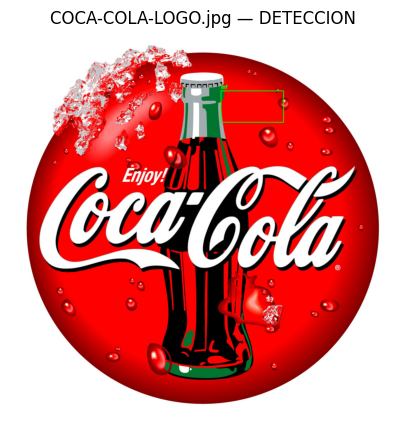

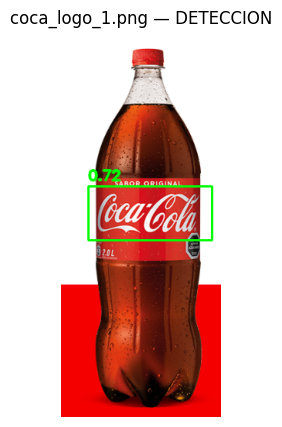

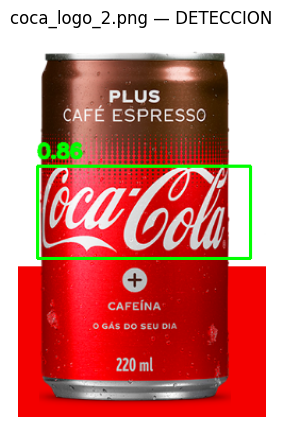

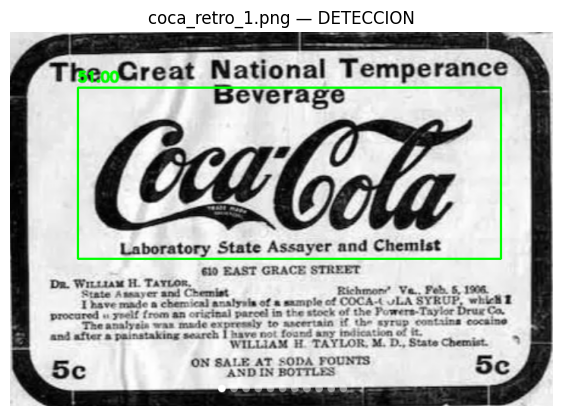

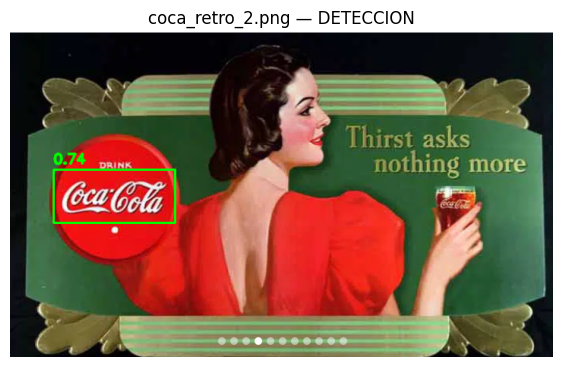

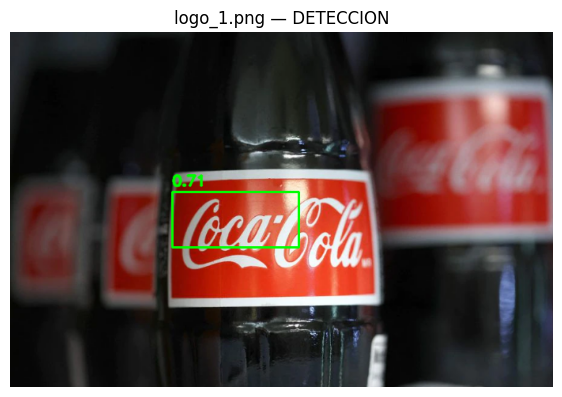

In [9]:
for p in paths:
    name = p.name
    bgr = cv.imread(str(p))
    rgb = to_rgb(bgr)
    gray = to_gray(bgr)
    tpl_gray = to_gray(tpl_bgr)

    if name == "coca_logo_2.png":
        score, loc, (w, h), _ = best_match_multiscale_edges(
            gray, tpl_gray, np.linspace(0.45, 2.2, 36), soft=True
        )
        boxes = [[loc[0], loc[1], w, h, score]]

    elif name == "coca_retro_1.png":
        x, y, w, h, n = detect_akaze_h(tpl_bgr, bgr, ratio=0.80, min_matches=10, ransac_px=6.0)
        boxes = [[x, y, w, h, float(n)]]

    else:
        boxes = tm_multiroi(
            image_bgr=bgr,
            template_bgr=tpl_bgr,
            scales=SCALES,
            angles=ANGLES,
            thr_map=THR_TM,
            edge_fn=edges_loose,
            gate_red=GATE_RED,     
            min_roi_area=800
        )

    x, y, w, h, score = max(boxes, key=lambda t: t[4])
    draw_box(rgb, (x, y), w, h, score, (0, 255, 0))

    plt.figure(figsize=(7, 5))
    plt.imshow(rgb)
    plt.axis('off')
    plt.title(f"{name} — DETECCION")
    plt.show()

Se lograron aciertos en cinco de seis casos. La única falla clara es el primer ejemplo, donde el template matching se engancha con un borde fuerte que no es el logo. Si bien se intentaron probar varios caminos no se logro detectar correctamente el logo en la primer imagen.


#### Punto 2: Plantear y validar un algoritmo para múltiples detecciones en la imagen coca_multi.png con el mismo témplate del ítem 1

In [10]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

#ruta a la imagen con detección múltiple
IMG_PATH = Path('../Material_TPs/TP3/images/coca_multi.png')

Se definen funciones que se van a emplear mas de una vez: una versión simple de Canny en gris, una función para bajar el template con pirámide gaussiana y un NMS que elimina superposiciones. En este NMS ordeno por score de respuesta para quedarme primero con las detecciones más fuertes. Antes de quedarnos con este esquema, se probaron otras variantes. Se intento aplicar una correlación en bordes con máscara combinada con rotación/escala, chequeo de orientación del gradiente, verificación por intensidad y hasta un filtrado por color rojo. En esta imagen de la gondola hay muchas texturas repetidas (rejitas, brillos y bordes de estantes), y estas opciones tendían a producir mapas de respuesta ruidosos, con cajas duplicadas y sensibilidad alta a parámetros. También probamos puntos clave + homografía. En escenas difíciles rinde muy bien, pero en esta góndola fue más lento, dependía de tener suficientes puntos en cada etiqueta y no a fin de cuentas no mejoraba lo que logramos con una correlación bien preprocesada cuando las botellas están alineadas y a tamaño parecido.

In [11]:
def _canny_gray(bgr, lo, hi):
    g = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)
    if lo == 0 and hi == 0:
        return g
    return cv.Canny(g, lo, hi)

def _pyr_down(img, level=0):
    out = img
    for _ in range(level):
        out = cv.pyrDown(out)
    return out

def _nms_iou(boxes, overlap=0.30):
    """Non-Max Suppression clásico (IoU). Espera array (N,4) [x1,y1,x2,y2]."""
    if len(boxes) == 0:
        return np.empty((0,4), dtype=int)
    b = boxes.astype("float")

    x1, y1, x2, y2 = b[:,0], b[:,1], b[:,2], b[:,3]
    area = (x2 - x1 + 1) * (y2 - y1 + 1)
    idx = np.argsort(y2) 

    keep = []
    while len(idx) > 0:
        i = idx[-1]
        keep.append(i)

        xx1 = np.maximum(x1[i], x1[idx[:-1]])
        yy1 = np.maximum(y1[i], y1[idx[:-1]])
        xx2 = np.minimum(x2[i], x2[idx[:-1]])
        yy2 = np.minimum(y2[i], y2[idx[:-1]])

        w = np.maximum(0, xx2 - xx1 + 1)
        h = np.maximum(0, yy2 - yy1 + 1)
        inter = w * h
        iou = inter / (area[i] + area[idx[:-1]] - inter + 1e-9)

        idx = idx[np.where(iou <= overlap)[0]]
    return b[keep].astype(int)


El detector multi-instancia lo planteamos deliberadamente simple por la naturaleza de coca_multi.png: las etiquetas tienen tamaño parecido, están casi sin rotación y con vista frontal. En este contexto, conviene resaltar contornos con Canny usando umbrales distintos para imagen (más alto con bordes limpios) y template (más bajo con bordes finos), ajustar la escala del template con una pequeña pirámide para que calce con la góndola, y aplicar matchTemplate con una métrica estable (TM_CCOEFF_NORMED). Usamos un umbral bajo para levantar candidatos y después limpiamos los solapamientos con NMS. Este pipeline es rápido, determinista, fácil de tunear (umbral, nivel de pirámide, IoU) y, sobre todo, se comporta mejor que otras alternativas en esta imagen concreta, donde la repetición regular del patrón favorece a la correlación clásica.

In [12]:
def detectar_varios_tm(
    img_bgr, tpl_bgr,
    canny_img=(200, 500),      # imagen: bordes fuertes
    canny_tpl=(5,   500),      # template: bordes finos
    tpl_pyr_level=2,           # template reducido para la góndola
    metodo=cv.TM_CCOEFF_NORMED,
    thr=0.19,                  # umbral crudo sobre el mapa de respuestas
    iou_nms=0.30               # consolidación por IoU
):
    # 1) preprocesado
    img_proc = _canny_gray(img_bgr, *canny_img)
    tpl_proc = _canny_gray(tpl_bgr, *canny_tpl)
    tpl_proc = _pyr_down(tpl_proc, tpl_pyr_level)

    # 2) template matching
    R = cv.matchTemplate(img_proc, tpl_proc, metodo)
    th, tw = tpl_proc.shape[:2]

    # 3) candidatos por umbral
    ys, xs = np.where(R >= thr)
    rects = np.array([[x, y, x+tw, y+th] for (x, y) in zip(xs, ys)], dtype=int)

    # 4) NMS
    rects_nms = _nms_iou(rects, overlap=iou_nms) if len(rects) else rects

    # 5) confianza por min-max del mapa
    R_norm = cv.normalize(R, None, alpha=0.0, beta=1.0, norm_type=cv.NORM_MINMAX)
    probs = [float(R_norm[y1, x1]) for (x1, y1, _, _) in rects_nms]

    return rects_nms.tolist(), probs, R, tpl_proc


Por último, cargo la imagen de góndola, corro el detector y dibujo las cajas con sus porcentajes.

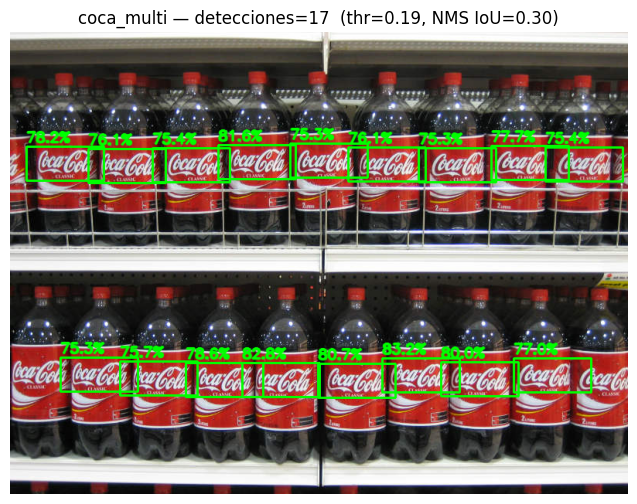

In [13]:
img = cv.imread(str(IMG_PATH), cv.IMREAD_COLOR)
tpl = cv.imread(str(TEMPLATE_PATH), cv.IMREAD_COLOR)

cajas, confs, R, tpl_proc = detectar_varios_tm(
    img, tpl,
    canny_img=(200,500), 
    canny_tpl=(5,500),
    tpl_pyr_level=2,
    metodo=cv.TM_CCOEFF_NORMED,
    thr=0.19,
    iou_nms=0.30
)

salida = cv.cvtColor(img.copy(), cv.COLOR_BGR2RGB)
for (x1,y1,x2,y2), p in zip(cajas, confs):
    cv.rectangle(salida, (x1,y1), (x2,y2), (0,255,0), 2)
    cv.putText(salida, f"{p*100:.1f}%", (x1, max(0,y1-6)),
               cv.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2, cv.LINE_AA)

plt.figure(figsize=(12,6))
plt.imshow(salida); plt.axis("off")
plt.title(f"coca_multi — detecciones={len(cajas)}  (thr=0.19, NMS IoU=0.30)")
plt.show()